## Chi Square Goodness Of Fit Test On Uniform Distribution

In [1]:
# Importing Basic Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import norm,uniform,poisson,chisquare,chi2
from statsmodels.graphics.gofplots import qqplot

C:\Users\hp\anaconda3\Lib\anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hp\anaconda3\Lib\anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
C:\Users\hp\AppData\Local\Temp/ipykernel_14800/609321381.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Reading The Data
df = pd.read_csv("uniformData.csv")

In [3]:
# Print Top 5 Rows From Data
df.head()

,obs
0,54.507318
1,52.183131
2,59.587585
3,52.951728
4,53.302821


In [4]:
# Print Shape Of The Data
df.shape

(51, 1)

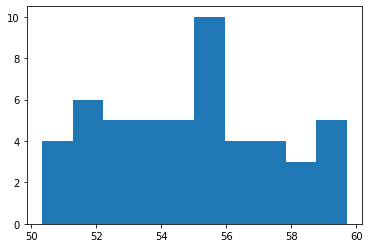

In [5]:
# Visualize The Data As A Histogram
plt.hist(df["obs"])
plt.show()

In [6]:
# Get The Descriptive Statistics For The Data
df.describe()

,obs
count,51.000000
mean,54.931441
std,2.633428
min,50.340227
25%,52.979121
50%,55.079462
75%,56.820487
max,59.695597


In [7]:
# Some Additional Descriptive Statistics
stats_labels = ["Variance Observed","Skew Observed","Kurt Observed"]
stats_values = [round(df["obs"].var(),2),round(df["obs"].skew(),2),round(df["obs"].kurt(),2)]
print(set(zip(stats_labels,stats_values)))

{('Kurt Observed', -0.83), ('Variance Observed', 6.93), ('Skew Observed', 0.18)}


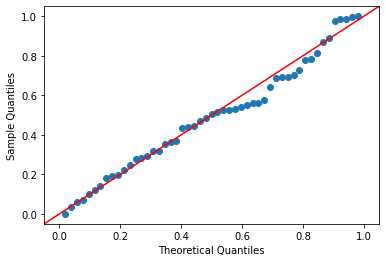

In [8]:
# Plot QQ To Compare The Quantiles (Amplify The Differences In The Tail)
sm.qqplot(df["obs"],uniform,fit=True,line='45')
plt.show()

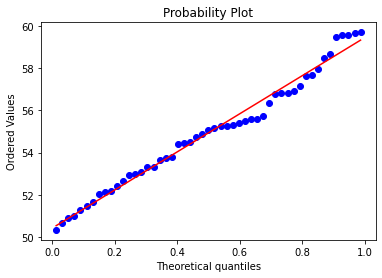

In [9]:
# Plot PP To Compare The Quantiles (Amplify The Differences In The Center)
stats.probplot(df["obs"],dist=uniform,plot=plt)
plt.show()

*Null Hypothesis : The given data follows Uniform Distribution*<br>
*Alternate Hypothesis : The given data does not follow Uniform Distribution.*

In [10]:
# Step-1 In Chi Square Goodness Of Fit : Create Bins
df["bins"] = pd.cut(df["obs"],bins=10)
df

,obs,bins
0,54.507318,"(54.082, 55.018]"
1,52.183131,"(51.276, 52.211]"
2,59.587585,"(58.76, 59.696]"
3,52.951728,"(52.211, 53.147]"
4,53.302821,"(53.147, 54.082]"
5,54.383157,"(54.082, 55.018]"
6,55.394090,"(55.018, 55.953]"
7,59.637172,"(58.76, 59.696]"
8,53.811463,"(53.147, 54.082]"
9,52.035259,"(51.276, 52.211]"


In [11]:
# Step-2 In Chi Square Goodness Of Fit : Count Number Of Obserations In Each Bin
df_2 = pd.DataFrame()
df_2["Observed Frequency"] = df.groupby("bins").count()
df_2

C:\Users\hp\AppData\Local\Temp/ipykernel_14800/371124284.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2["Observed Frequency"] = df.groupby("bins").count()


,Observed Frequency
bins,
"(50.331, 51.276]",4
"(51.276, 52.211]",6
"(52.211, 53.147]",5
"(53.147, 54.082]",5
"(54.082, 55.018]",5
"(55.018, 55.953]",10
"(55.953, 56.889]",4
"(56.889, 57.825]",4
"(57.825, 58.76]",3


In [12]:
# Step-3 In Chi Square Goodness Of Fit : Determine The Expected Number Of Observations In Each Bin
mean = df_2["Observed Frequency"].mean()
df_2["Expected Frequency"] = mean
df_2

,Observed Frequency,Expected Frequency
bins,,
"(50.331, 51.276]",4,5.1
"(51.276, 52.211]",6,5.1
"(52.211, 53.147]",5,5.1
"(53.147, 54.082]",5,5.1
"(54.082, 55.018]",5,5.1
"(55.018, 55.953]",10,5.1
"(55.953, 56.889]",4,5.1
"(56.889, 57.825]",4,5.1
"(57.825, 58.76]",3,5.1


In [13]:
# Step-4A In Chi Square Goodness Of Square Fit : Determine The Test Statistics And P-value
chisquare(df_2["Observed Frequency"],df_2["Expected Frequency"])

Power_divergenceResult(statistic=6.450980392156864, pvalue=0.6940703597580011)

*Conclusion*<br>
*Reject The Null If The Pvalue < Level Of Siginificance*<br>
*Do Not Reject The Null If the Pvalue >= Level Of Siginificance*<br>
*Say The Level Of Siginifance is 5%,Then For Given Data Set,P-value (0.694)>0.05-->Do Not Reject Null*<br>
*Note : For Any Leel Of Siginificance -->70%,We Do Not Reject The Null For The Current Data Set.*<br>

In [14]:
# Step-4B In Chi Square Goodness Of Square Fit : Determine The Tabulated Value Of The Test Statistics
chi2.ppf(0.95,len(df_2)-2-1)

14.067140449340169

*Conclusion*<br>
*Reject The Null If The Tabulated Test Statistic Value < Computed Test Statistics Value*<br>
*Do Not Reject The Null If The Tabulated Test Statistics Value >=  Computed Test Statistics Value*

## Chi Square Goodness Of Fit Test On Poisson Distribution

In [15]:
# Reading The Data
df = pd.read_csv("poissonData.csv")

In [16]:
# Print Top 5 Rows From Data
df.head()

,obs
0,5
1,4
2,4
3,5
4,5


In [17]:
# Print Shape Of The Data
df.shape

(100, 1)

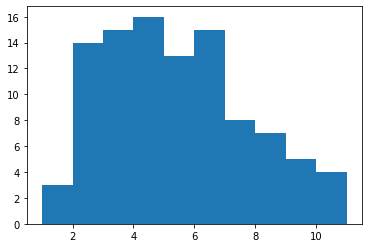

In [18]:
# Visualize The Data As A Histogram
plt.hist(df["obs"])
plt.show()

In [19]:
# Get The Descriptive Statistics For The Data
df.describe()

,obs
count,100.000000
mean,4.940000
std,2.381834
min,1.000000
25%,3.000000
50%,5.000000
75%,6.000000
max,11.000000


In [20]:
# Some Additional Descriptive Statistics
stats_labels = ["Variance Observed","Skew Observed","Kurt Observed"]
stats_values = [round(df["obs"].var(),2),round(df["obs"].skew(),2),round(df["obs"].kurt(),2)]
print(set(zip(stats_labels,stats_values)))

{('Kurt Observed', -0.38), ('Skew Observed', 0.51), ('Variance Observed', 5.67)}


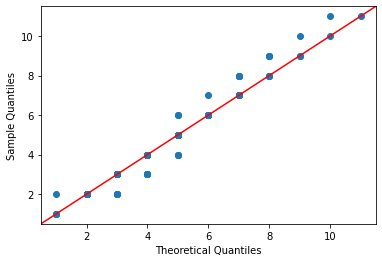

In [21]:
# Plot QQ To Compare The Quantiles (Amplify The Differences In The Tail)
sm.qqplot(df["obs"], poisson(np.mean(df["obs"])), line='45')
plt.show()

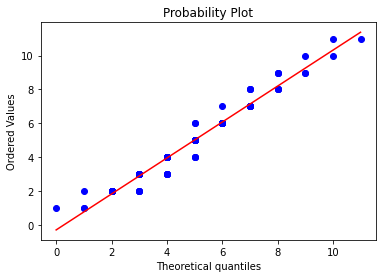

In [22]:
# Plot PP To Compare The Quantiles (Amplify The Differences In The Center)
stats.probplot(df["obs"],dist="poisson",sparams=(np.mean(df["obs"]),),plot=plt)
plt.show()

*Null Hypothesis : The given data follows Poisson Distribution*<br>
*Alternate Hypothesis : The given data does not follow Poisson Distribution.*

In [23]:
# Step-1 In Chi Square Goodness Of Fit : Create Bins
df["bins"] = pd.cut(df["obs"],bins=10)
df

,obs,bins
0,5,"(4.0, 5.0]"
1,4,"(3.0, 4.0]"
2,4,"(3.0, 4.0]"
3,5,"(4.0, 5.0]"
4,5,"(4.0, 5.0]"
...,...,...
95,6,"(5.0, 6.0]"
96,8,"(7.0, 8.0]"
97,6,"(5.0, 6.0]"
98,2,"(0.99, 2.0]"


In [24]:
# Step-2 In Chi Square Goodness Of Fit : Count Number Of Obserations In Each Bin
grouped_df = pd.DataFrame()
grouped_df["Observed Frequency"] = df.groupby("obs").count()
grouped_df

,Observed Frequency
obs,
1,3
2,14
3,15
4,16
5,13
6,15
7,8
8,7
9,5


In [25]:
# Step-3 In Chi Square Goodness Of Fit : Determine The Expected Number Of Observations In Each Bin
# Step3A : Determine The Poisson PMF For Each Bucket
grouped_df["POISSON_PMF"] = poisson.pmf(k=grouped_df.index,mu=df["obs"].mean())
grouped_df

,Observed Frequency,POISSON_PMF
obs,,
1,3,0.035344
2,14,0.087299
3,15,0.143752
4,16,0.177534
5,13,0.175404
6,15,0.144416
7,8,0.101916
8,7,0.062933
9,5,0.034543


In [26]:
# Step3B : Determined The Expected Frequency In Each Bucket
grouped_df["Expected Frequency"] = grouped_df["POISSON_PMF"] * len(df)
grouped_df

,Observed Frequency,POISSON_PMF,Expected Frequency
obs,,,
1,3,0.035344,3.534372
2,14,0.087299,8.729898
3,15,0.143752,14.375232
4,16,0.177534,17.753411
5,13,0.175404,17.540370
6,15,0.144416,14.441572
7,8,0.101916,10.191623
8,7,0.062933,6.293327
9,5,0.034543,3.454337


In [27]:
print("Observed Frequency : ",grouped_df["Observed Frequency"].sum())
print("Expected Frequency : ",grouped_df["Expected Frequency"].sum())

Observed Frequency :  100
Expected Frequency :  98.78693324867051


In [28]:
grouped_df.iloc[10:,:] = [2,1-grouped_df.iloc[:10,:]["POISSON_PMF"].sum(),(1-grouped_df.iloc[:10,:]["POISSON_PMF"].sum())*len(df)]

In [29]:
print("Observed Frequency : ",grouped_df["Observed Frequency"].sum())
print("Expected Frequency : ",grouped_df["Expected Frequency"].sum())

Observed Frequency :  100
Expected Frequency :  99.99999999999999


In [30]:
# Step-4A In Chi Square Goodness Of Square Fit : Determine The Test Statistics And P-value
chisquare(grouped_df["Observed Frequency"],grouped_df["Expected Frequency"])

Power_divergenceResult(statistic=5.952451178440336, pvalue=0.8192421366218877)

*Conclusion*<br>
*Reject The Null If The Pvalue < Level Of Siginificance*<br>
*Do Not Reject The Null If the Pvalue >= Level Of Siginificance*<br>
*Say The Level Of Siginifance is 5%,Then For Given Data Set,P-value (0.634)>0.05-->Do Not Reject Null*<br>
*Note : For Any Leel Of Siginificance -->70%,We Do Not Reject The Null For The Current Data Set.*<br>

In [31]:
# Step-4B In Chi Square Goodness Of Square Fit : Determine The Tabulated Value Of The Test Statistics
chi2.ppf(0.95,len(grouped_df)-1-1)

16.918977604620448

*Conclusion*<br>
*Reject The Null If The Tabulated Test Statistic Value < Computed Test Statistics Value*<br>
*Do Not Reject The Null If The Tabulated Test Statistics Value >=  Computed Test Statistics Value*

## Chi Square Goodness Of Fit Test On Poisson Distribution

In [32]:
# Reading The Data
df = pd.read_csv("GOF.csv")
df

,obs
0,6
1,1
2,5
3,9
4,4
...,...
95,5
96,5
97,5
98,0


In [33]:
# Print Top 5 Rows From Data
df.head()

,obs
0,6
1,1
2,5
3,9
4,4


In [34]:
# Print Shape Of The Data
df.shape

(100, 1)

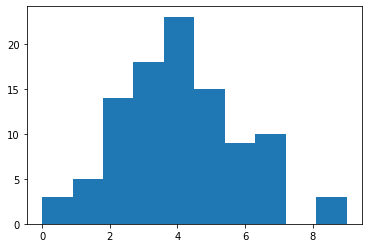

In [35]:
# Visualize The Data As A Histogram
plt.hist(df["obs"])
plt.show()

In [36]:
# Get The Descriptive Statistics For The Data
df.describe()

,obs
count,100.000000
mean,4.050000
std,1.966256
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,9.000000


In [37]:
# Some Additional Descriptive Statistics
stats_labels = ["Variance Observed","Skew Observed","Kurt Observed"]
stats_values = [round(df["obs"].var(),2),round(df["obs"].skew(),2),round(df["obs"].kurt(),2)]
print(set(zip(stats_labels,stats_values)))

{('Skew Observed', 0.3), ('Variance Observed', 3.87), ('Kurt Observed', -0.07)}


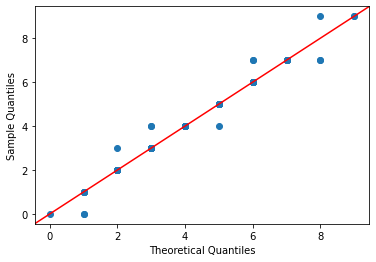

In [38]:
# Plot QQ To Compare The Quantiles (Amplify The Differences In The Tail)
sm.qqplot(df["obs"], poisson(np.mean(df["obs"])), line='45')
plt.show()

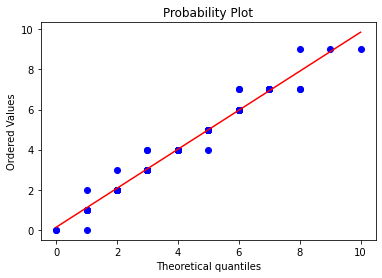

In [39]:
# Plot PP To Compare The Quantiles (Amplify The Differences In The Center)
stats.probplot(df["obs"],dist="poisson",sparams=(np.mean(df["obs"]),),plot=plt)
plt.show()

In [40]:
# Step-1 In Chi Square Goodness Of Fit : Create Bins
df["bins"] = pd.cut(df["obs"],bins=10)
df

,obs,bins
0,6,"(5.4, 6.3]"
1,1,"(0.9, 1.8]"
2,5,"(4.5, 5.4]"
3,9,"(8.1, 9.0]"
4,4,"(3.6, 4.5]"
...,...,...
95,5,"(4.5, 5.4]"
96,5,"(4.5, 5.4]"
97,5,"(4.5, 5.4]"
98,0,"(-0.009, 0.9]"


In [41]:
# Step-2 In Chi Square Goodness Of Fit : Count Number Of Obserations In Each Bin
grouped_df = pd.DataFrame()
grouped_df["Observed Frequency"] = df.groupby("obs").count()
grouped_df

,Observed Frequency
obs,
0,3
1,5
2,14
3,18
4,23
5,15
6,9
7,10
9,3


In [42]:
# Step-3 In Chi Square Goodness Of Fit : Determine The Expected Number Of Observations In Each Bin
# Step3A : Determine The Poisson PMF For Each Bucket
grouped_df["POISSON_PMF"] = poisson.pmf(k=grouped_df.index,mu=df["obs"].mean())
grouped_df

,Observed Frequency,POISSON_PMF
obs,,
0,3,0.017422
1,5,0.070561
2,14,0.142885
3,18,0.192895
4,23,0.195306
5,15,0.158198
6,9,0.106784
7,10,0.061782
9,3,0.014075


In [43]:
# Step3B : Determined The Expected Frequency In Each Bucket
grouped_df["Expected Frequency"] = grouped_df["POISSON_PMF"] * len(df)
grouped_df

,Observed Frequency,POISSON_PMF,Expected Frequency
obs,,,
0,3,0.017422,1.742237
1,5,0.070561,7.056062
2,14,0.142885,14.288525
3,18,0.192895,19.289509
4,23,0.195306,19.530628
5,15,0.158198,15.819808
6,9,0.106784,10.678371
7,10,0.061782,6.178200
9,3,0.014075,1.407471


In [44]:
print("Observed Frequency : ",grouped_df["Observed Frequency"].sum())
print("Expected Frequency : ",grouped_df["Expected Frequency"].sum())

Observed Frequency :  100
Expected Frequency :  95.99081095164381


In [45]:
# Since Expected Frequency Not Equal To Observed Frequency  
grouped_df.drop([9],inplace=True)
grouped_df.loc[len(grouped_df)] = [df.shape[0]-grouped_df["Observed Frequency"].sum(),1-grouped_df["POISSON_PMF"].sum(),(1-grouped_df["POISSON_PMF"].sum())* len(df)]

In [46]:
print("Observed Frequency : ",grouped_df["Observed Frequency"].sum())
print("Expected Frequency : ",grouped_df["Expected Frequency"].sum())

Observed Frequency :  100.0
Expected Frequency :  100.0


In [47]:
# Step-4A In Chi Square Goodness Of Square Fit : Determine The Test Statistics And P-value
chisquare(grouped_df["Observed Frequency"],grouped_df["Expected Frequency"])

Power_divergenceResult(statistic=5.964070009119779, pvalue=0.6512567264525931)

In [48]:
# Step-4B In Chi Square Goodness Of Square Fit : Determine The Tabulated Value Of The Test Statistics
chi2.ppf(0.95,len(grouped_df)-1-1)

14.067140449340169